# 반도체 공정 스케줄링 시뮬레이션 결과

## 환경 설정

In [23]:
import os
import simpy
from dotenv import load_dotenv
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Noto Sans KR'
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# .env 파일의 환경 변수 로드
load_dotenv()

# .env 파일의 파라미터
BASE_DATA_PATH = os.getenv('BASE_DATA_PATH', 'data')
PM_HAZARD_THRESHOLD = os.getenv('PM_HAZARD_THRESHOLD', '0.1')
QTIME_URGENCY_FACTOR = os.getenv('QTIME_URGENCY_FACTOR', '1.5')
PM_ACTIVE = os.getenv('PM_ACTIVE', 'True').lower() == 'true'
DOWN_ACTIVE = os.getenv('DOWN_ACTIVE', 'True').lower() == 'true'
MACHINE_CHOICE= os.getenv('MACHINE_CHOICE', 'FIFO')
print(f"BASE_DATA_PATH: {BASE_DATA_PATH}")
print(f"PM_HAZARD_THRESHOLD: {PM_HAZARD_THRESHOLD}")
print(f"QTIME_URGENCY_FACTOR: {QTIME_URGENCY_FACTOR}")
print(f"PM_ACTIVE: {PM_ACTIVE}")
print(f"DOWN_ACTIVE: {DOWN_ACTIVE}")
print(f"MACHINE_CHOICE: {MACHINE_CHOICE}")

BASE_DATA_PATH: data
PM_HAZARD_THRESHOLD: 0.2
QTIME_URGENCY_FACTOR: 1.5
PM_ACTIVE: True
DOWN_ACTIVE: True
MACHINE_CHOICE: FIFO


## 모듈 import

In [24]:
from utils import DataLoader, EventLogger
from utils.visualizer import create_gantt_chart
from simulation import Scheduler

## 데이터 로드

In [25]:
data_loader = DataLoader(BASE_DATA_PATH)

data = data_loader.load_all_data()

print("=" * 60)
print("데이터 개요")
print("=" * 60)
print(f"Jobs: {len(data['jobs'])} 개")
print(f"Operations: {len(data['operations'])} 개")
print(f"Machines: {len(data['machines'])} 개")
print(f"Machine Failures: {len(data['machine_failure'])} 개")
print(f"Setup Times: {len(data['setup_times'])} 개")
print(f"Operation-Machine Map: {len(data['operation_machine_map'])} 개")

데이터 개요
Jobs: 10 개
Operations: 35 개
Machines: 8 개
Machine Failures: 8 개
Setup Times: 12 개
Operation-Machine Map: 95 개


## 시뮬레이션 실행

In [26]:
import random
random.seed(42)

# SimPy 환경 생성
env = simpy.Environment()

# 이벤트 로거 생성
event_logger = EventLogger(env)

# 스케줄러 생성
scheduler = Scheduler(env=env,
                      data=data,
                      event_logger=event_logger,
                      pm_hazard_threshold=float(PM_HAZARD_THRESHOLD),
                      qtime_urgency_factor=float(QTIME_URGENCY_FACTOR))

In [27]:
env.run(until=scheduler.job_chk_process)
fig = create_gantt_chart(
    logs=event_logger.logs,
    max_time=env.now,
    title=f"반도체 공정 간트 차트 (Simulation Time: {round(env.now, 3)})")
fig.show()

## 시뮬레이션 KPI 및 통계

### 작업별 통계

In [28]:
scheduler.get_simulation_info()

Job ID: J1	QTime Violation: 13.0	완료 시간: 85
Job ID: J2	QTime Violation: 0.0	완료 시간: 33
Job ID: J3	QTime Violation: 18.0	완료 시간: 99
Job ID: J4	QTime Violation: 16.0	완료 시간: 83
Job ID: J5	QTime Violation: 31.0	완료 시간: 111
Job ID: J6	QTime Violation: 30.0	완료 시간: 89
Job ID: J7	QTime Violation: 12.0	완료 시간: 106
Job ID: J8	QTime Violation: 0.0	완료 시간: 119
Job ID: J9	QTime Violation: 25.0	완료 시간: 121
Job ID: J10	QTime Violation: 22.0	완료 시간: 128
시뮬레이션 시간: 128
총 작업 수: 10
완료된 작업 수: 10
기한 안에 완료된 작업 수: 10
총 QTime 위반 시간: 167.0


### op_id별 작업 시작/종료 시간 (qtime violation 검증용)

In [29]:
df_logs = pd.DataFrame(event_logger.logs)

# job 이벤트만, op_id 있는 행만
df_job_ops = (
    df_logs[(df_logs['resource'] == 'job') & (df_logs['op_id'].notna())]
    .copy()
    [['id', 'op_id', 'event', 'start', 'finish']]
    .rename(columns={'id': 'job_id'})
    .sort_values(['job_id', 'op_id', 'start'])
    .reset_index(drop=True)
)

# qtime 허용값 붙이기
qtime_map = data['operations'].set_index('op_id')['qtime']
df_job_ops['qtime_limit'] = df_job_ops['op_id'].map(qtime_map)

# waiting 시작(= 이전 op 완료 시점) ~ working 시작까지 경과 시간으로 violation 계산
waiting = df_job_ops[df_job_ops['event'] == 'waiting'][['job_id', 'op_id', 'start']].rename(columns={'start': 'waiting_start'})
working = df_job_ops[df_job_ops['event'] == 'working'][['job_id', 'op_id', 'start']].rename(columns={'start': 'working_start'})
qtime_check = waiting.merge(working, on=['job_id', 'op_id'], how='inner')
qtime_check['actual_wait'] = round(qtime_check['working_start'] - qtime_check['waiting_start'], 3)
qtime_check['qtime_limit'] = qtime_check['op_id'].map(qtime_map)
qtime_check['violation']   = round((qtime_check['actual_wait'] - qtime_check['qtime_limit']).clip(lower=0), 3)

display(df_job_ops)
print("\n--- qtime 위반 검증 (waiting 시작 → working 시작) ---")
display(qtime_check[qtime_check['violation'] > 0])
print(f"\n독립 계산 총 위반 시간: {qtime_check['violation'].sum()}")
print(f"시뮬레이션 내부 총 위반 시간: {sum(j.total_qtime_over for j in scheduler._Scheduler__jobs)}")

,job_id,op_id,event,start,finish,qtime_limit
0,J1,J1_O1,waiting,0.0,0.0,NaN
1,J1,J1_O1,setup,0.0,0.0,NaN
2,J1,J1_O1,working,0.0,11.0,NaN
3,J1,J1_O2,waiting,11.0,11.0,20.0
4,J1,J1_O2,setup,11.0,11.0,20.0
5,J1,J1_O2,working,11.0,26.0,20.0
6,J1,J1_O3,waiting,26.0,39.0,12.0
7,J1,J1_O3,setup,39.0,39.0,12.0
8,J1,J1_O3,working,39.0,64.0,12.0
9,J1,J1_O4,waiting,64.0,64.0,18.0



--- qtime 위반 검증 (waiting 시작 → working 시작) ---


,job_id,op_id,waiting_start,working_start,actual_wait,qtime_limit,violation
2,J1,J1_O3,26.0,39.0,13.0,12.0,1.0
5,J10,J10_O2,74.0,96.0,22.0,14.0,8.0
12,J3,J3_O3,54.0,72.0,18.0,14.0,4.0
15,J4,J4_O2,28.0,44.0,16.0,12.0,4.0
19,J5,J5_O3,38.0,69.0,31.0,20.0,11.0
22,J6,J6_O2,34.0,64.0,30.0,14.0,16.0
32,J9,J9_O2,48.0,73.0,25.0,15.0,10.0



독립 계산 총 위반 시간: 54.0
시뮬레이션 내부 총 위반 시간: 167.0


,waiting,setup,working,job_type
id,,,,
J1,13.0,0.0,72.0,P1
J3,35.0,7.0,57.0,P1
J5,42.0,0.0,69.0,P1
J7,50.0,0.0,56.0,P1
J9,58.0,0.0,63.0,P1
J10,73.0,6.0,49.0,P2
J2,0.0,0.0,33.0,P2
J4,26.0,0.0,57.0,P2
J6,45.0,4.0,40.0,P2


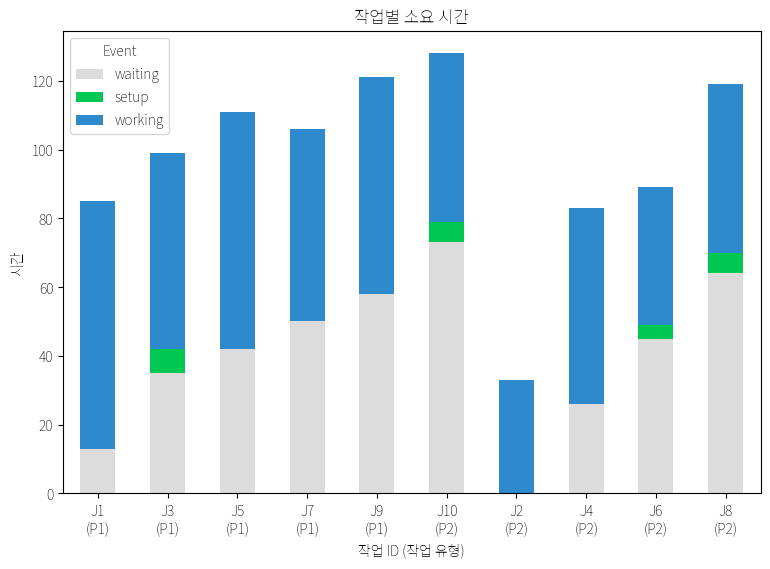

In [30]:
df_logs = pd.DataFrame(event_logger.logs)
job_info = df_logs[df_logs['resource'] == 'job']
job_info['duration'] = round(job_info['finish'] - job_info['start'], 3)
job_info = job_info.groupby(['id', 'event'])['duration'].sum().reset_index(['id', 'event'], drop=False)
job_stacked = job_info.pivot(index='id', columns='event', values='duration').fillna(0)
job_stacked = job_stacked.reindex(columns=['waiting', 'setup', 'working'], fill_value=0)
job_type_map = data['jobs'].set_index('job_id')['job_type']
job_stacked = job_stacked.join(job_type_map).sort_values('job_type')
display(job_stacked)
job_stacked.index = [f"{i}\n({t})" for i, t in zip(job_stacked.index, job_stacked['job_type'])]
job_stacked.plot(kind='bar', stacked=True, figsize=(9, 6), color={
    "waiting": '#DCDCDC',
    "setup": '#00C853',
    "working": '#2E89CD'
})
plt.title("작업별 소요 시간")
plt.xlabel("작업 ID (작업 유형)")
plt.ylabel("시간")
plt.xticks(rotation=0)
plt.legend(title="Event")
plt.show()

### 공정별 설비 활용률

,utilization,group
id,,
M1,0.640625,G1
M2,0.617188,G1
M3,0.625000,G1
M4,0.531250,G2
M5,0.656250,G2
M6,0.429688,G3
M7,0.375000,G3
M8,0.382812,G3


C:\Users\User\AppData\Local\Temp\ipykernel_21396\590967979.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=machine_utilization, x='group', y='utilization',


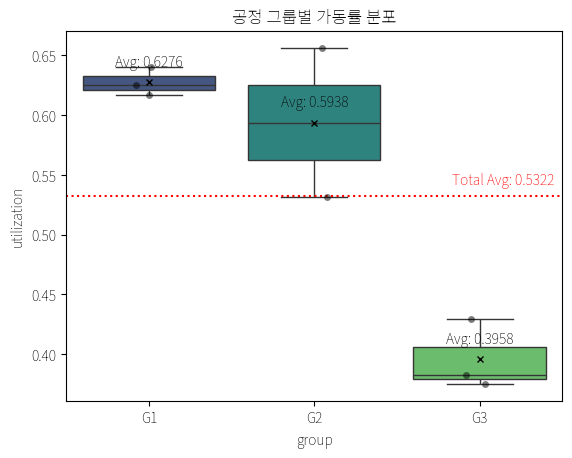

In [31]:
df_logs = pd.DataFrame(event_logger.logs)
machine_info = df_logs[df_logs['resource'] == 'machine']
machine_info['utilization'] = machine_info['finish'] - machine_info['start']
machine_utilization = pd.DataFrame(machine_info[machine_info['event'] == 'working'].groupby('id')['utilization'].sum() / env.now)
machine_utilization['group'] = data['machines'].set_index('machine_id').loc[machine_utilization.index]['machine_group']
display(machine_utilization)
group_means = machine_utilization.groupby('group')['utilization'].mean()
total_mean = machine_utilization['utilization'].mean()
sns.boxplot(data=machine_utilization, x='group', y='utilization', 
            palette='viridis', showmeans=True,
            meanprops={"marker":"x", "markeredgecolor":"black", "markersize":"5"})
sns.stripplot(data=machine_utilization, x='group', y='utilization', 
              color='black', alpha=0.5, jitter=True)
for i, group in enumerate(group_means.index):
    mean_val = group_means[group]
    plt.text(i, mean_val + 0.01, f'Avg: {mean_val:.4f}', 
             ha='center', va='bottom', color='black', fontweight='bold')
plt.text(len(group_means)-0.55, total_mean + 0.01, f'Total Avg: {total_mean:.4f}', color='red', fontweight='bold', ha='right')
plt.axhline(total_mean, color='red', linestyle=':')
plt.title("공정 그룹별 가동률 분포")
plt.show()

---
## 룰 비교 실험 (베이스라인)

FIFO / SPT / random 세 가지 룰을 동일 시드로 반복 실행하여 KPI를 비교합니다.

In [32]:
import importlib
import simulation, utils

def run_simulation(rule: str, seed: int = 42) -> dict:
    random.seed(seed)

    # 모듈 재로드 (셀 재실행 시 상태 초기화)
    importlib.reload(simulation)
    importlib.reload(utils)
    from simulation import Scheduler
    from utils import EventLogger

    os.environ['MACHINE_CHOICE'] = rule

    _env = simpy.Environment()
    _logger = EventLogger(_env)
    _scheduler = Scheduler(
        env=_env,
        data=data,
        event_logger=_logger,
        pm_hazard_threshold=float(PM_HAZARD_THRESHOLD),
        qtime_urgency_factor=float(QTIME_URGENCY_FACTOR),
    )
    _env.run(until=_scheduler.job_chk_process)

    completed, due_ok, qtime_total = 0, 0, 0.0
    for job in _scheduler._Scheduler__jobs:
        completed += int(job.completed_time > 0.0)
        due_ok    += int(job.is_in_due_date())
        qtime_total += job.total_qtime_over

    return {
        'rule':              rule,
        'makespan':          round(_env.now, 3),
        'completed_jobs':    completed,
        'due_date_met':      due_ok,
        'qtime_violation':   round(qtime_total, 3),
    }

RULES = ['FIFO', 'SPT', 'random']
results = [run_simulation(r) for r in RULES]

df_compare = pd.DataFrame(results).set_index('rule')
display(df_compare)

# 복원
os.environ['MACHINE_CHOICE'] = MACHINE_CHOICE

,makespan,completed_jobs,due_date_met,qtime_violation
rule,,,,
FIFO,128,10,10,167.0
SPT,147,10,10,19.0
random,159,10,10,21.0


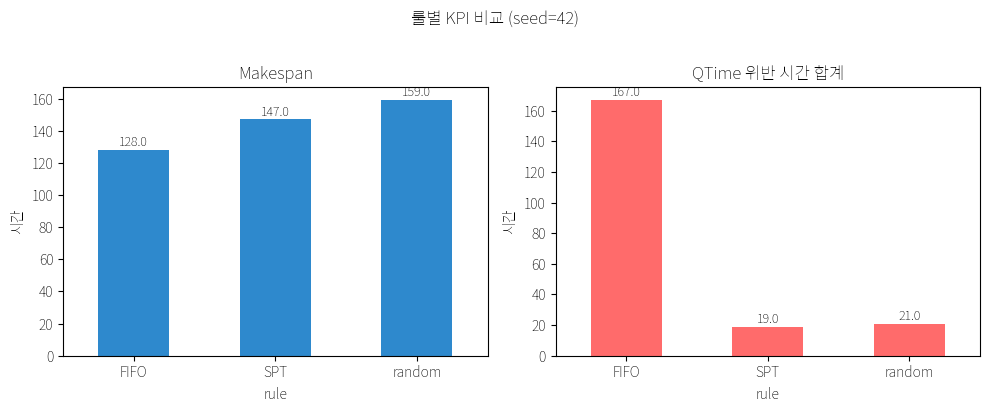

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

df_compare['makespan'].plot(kind='bar', ax=axes[0], color='#2E89CD', rot=0)
axes[0].set_title('Makespan')
axes[0].set_ylabel('시간')
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)

df_compare['qtime_violation'].plot(kind='bar', ax=axes[1], color='#FF6B6B', rot=0)
axes[1].set_title('QTime 위반 시간 합계')
axes[1].set_ylabel('시간')
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('룰별 KPI 비교 (seed=42)', y=1.02)
plt.tight_layout()
plt.show()